In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import torchvision
import torchvision.transforms as transforms

print("Libraries imported.")

Libraries imported.


In [6]:
# Load CIFAR-10 (RGB). We will convert to grayscale later for ORB.
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

X_train = train_dataset.data
y_train = np.array(train_dataset.targets)

X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

print("Full training images:", X_train.shape)
print("Full test images:", X_test.shape)

# Use a subset for the classical CV pipeline (for computational reasons)
N_TRAIN = 2000
N_TEST = 1000

X_train_sub = X_train[:N_TRAIN]
y_train_sub = y_train[:N_TRAIN]

X_test_sub = X_test[:N_TEST]
y_test_sub = y_test[:N_TEST]

print("Subset training images:", X_train_sub.shape)
print("Subset test images:", X_test_sub.shape)

Full training images: (50000, 32, 32, 3)
Full test images: (10000, 32, 32, 3)
Subset training images: (2000, 32, 32, 3)
Subset test images: (1000, 32, 32, 3)


In [11]:
# ORB feature extractor (resizing CIFAR images for stable feature detection)
orb = cv2.ORB_create(nfeatures=500)

def extract_orb_features(images):
    all_descriptors = []
    image_descriptors = []

    for img in images:
        img_uint8 = img.astype(np.uint8)

        # Upscale image for ORB
        img_resized = cv2.resize(img_uint8, (96, 96))

        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = orb.detectAndCompute(gray, None)

        if descriptors is not None and len(descriptors) > 0:
            all_descriptors.append(descriptors)
            image_descriptors.append(descriptors)
        else:
            dummy = np.zeros((1, 32), dtype=np.uint8)
            all_descriptors.append(dummy)
            image_descriptors.append(dummy)

    all_descriptors = np.vstack(all_descriptors)
    return image_descriptors, all_descriptors


# Extract ORB features for the training subset
train_img_descs, train_all_descs = extract_orb_features(X_train_sub)

print("Total ORB descriptors (train subset):", train_all_descs.shape)

Total ORB descriptors (train subset): (26368, 32)


In [13]:
# Number of visual words (reduced for CIFAR + ORB stability)
K = 40

kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
kmeans.fit(train_all_descs)

print("BoVW dictionary built with K =", K)

BoVW dictionary built with K = 40


In [14]:
def build_bovw_histograms(image_descriptors, kmeans, K):
    histograms = []

    for desc in image_descriptors:
        words = kmeans.predict(desc)
        hist, _ = np.histogram(words, bins=np.arange(K + 1))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)  # normalisation
        histograms.append(hist)

    return np.array(histograms)


X_train_bovw = build_bovw_histograms(train_img_descs, kmeans, K)
print("BoVW training feature shape:", X_train_bovw.shape)

BoVW training feature shape: (2000, 40)


In [15]:
# Extract ORB features for the test subset
test_img_descs, _ = extract_orb_features(X_test_sub)

# Build BoVW histograms for test images
X_test_bovw = build_bovw_histograms(test_img_descs, kmeans, K)

print("BoVW test feature shape:", X_test_bovw.shape)

BoVW test feature shape: (1000, 40)


In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_bovw, y_train_sub)

print("k-NN classifier trained.")

k-NN classifier trained.


In [17]:
y_pred = knn.predict(X_test_bovw)

test_accuracy = accuracy_score(y_test_sub, y_pred)
print("Classical CV Test Accuracy:", test_accuracy * 100, "%")

Classical CV Test Accuracy: 11.600000000000001 %


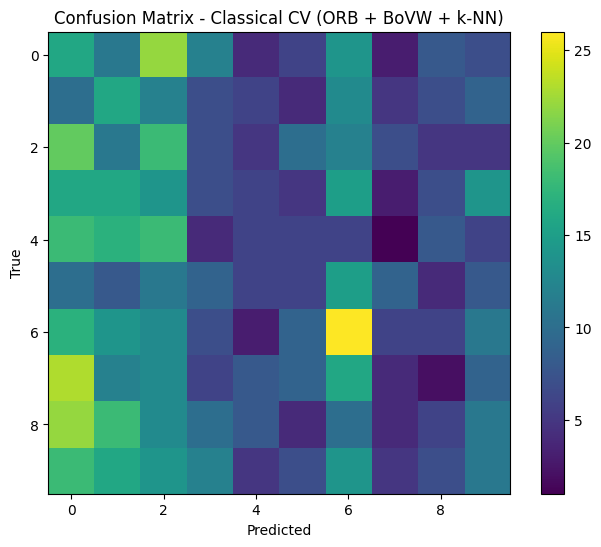

In [18]:
cm = confusion_matrix(y_test_sub, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - Classical CV (ORB + BoVW + k-NN)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()